# Fig. 2 — seqFISH+ mouse embryonic fibroblast data analysis

Reproduces Fig. 2a-l.

Data — set `SVC_DATA_ROOT` to the directory holding the prepared seqFISH+ arrays
(default: `../../data/seqfish`)
- `{train,test}_seqfish.npz`, `gene_names.txt` — registered transcript maps and the gene list
- `seqfish_data_dict.pkl`, `cell_mask_contour_preprocessed.pkl`,
  `nuclear_mask_contour_preprocessed.pkl` — measured transcript coordinates and cell outlines
  (Fig. 2c, Fig. 2j)

Precomputed files — `precomputed/`, shipped with this notebook
- `prediction_mu.npz`, `prediction_r.npz` — test-cell predictions of the final SVC model
  (seed 2026) (Fig. 2a-2g)
- `latent_test.npz`, `latent_train_mean_49genes.npz` — gene-level latent representations
  (Fig. 2e, Fig. 2k)
- `<method>_cell_gene_predictions.npy` — uniPort, ENVI, Tangram, gimVI (Fig. 2f)
- `instant_top1000_pairs.csv` — InSTAnT pair ranking (Fig. 2h)
- `svc_knn_coloc_counts.npz` and `svc_knn_coloc_counts_by_phase.npz` — per-cell 10-NN counts
  behind the gene co-localization score (Fig. 2h-2j, Fig. 2l)

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import wilcoxon

HERE = Path.cwd()

sys.path.insert(0, str(Path(os.environ.get('SVC_ROOT', HERE / '../..'))))   # github.com/aster-ww/SVC
DATA_DIR = Path(os.environ.get('SVC_DATA_ROOT', HERE / '../../data')) / 'seqfish'

# the 12 background corners of the 12x12 grid; every metric uses the 132 foreground pixels
BACKGROUND_PIXELS = np.array([[0, 0], [0, 1], [0, 10], [0, 11], [1, 0], [1, 11],
                              [10, 0], [10, 11], [11, 0], [11, 1], [11, 10], [11, 11]])
foreground = np.ones((12, 12), dtype=bool)
foreground[BACKGROUND_PIXELS[:, 0], BACKGROUND_PIXELS[:, 1]] = False
fg_idx = np.flatnonzero(foreground.reshape(-1))
n_fg = fg_idx.size

gene_names = np.loadtxt(DATA_DIR / 'gene_names.txt', dtype=str).tolist()
truth_test = np.load(DATA_DIR / 'test_seqfish.npz')['data_ori']
truth_train = np.load(DATA_DIR / 'train_seqfish.npz')['data_ori']
prediction = np.load(HERE / 'precomputed/prediction_mu.npz')['prediction']
n_cells, n_genes = truth_test.shape[:2]
print(prediction.shape)

(14, 1000, 12, 12)


## Fig. 2a — per-gene performance gains of SVC over the four baseline models, evaluated using PCC, cosine similarity and RMSE

In [2]:
def cosine_similarity(x1, x2, axis=1, eps=1e-8):
    denom = np.linalg.norm(x1, axis=axis) * np.linalg.norm(x2, axis=axis)
    return np.where(denom == 0, 0.0, np.sum(x1 * x2, axis=axis) / (denom + eps))


def eval_per_gene(pred):
    """Per-gene RMSE / cosine / spatial PCC against truth_test, averaged over test cells.
    PCC and cosine use cells whose measured image is non-empty."""
    rmse = np.zeros(n_genes)
    cosine = np.zeros(n_genes)
    pcc = np.zeros(n_genes)

    for i in range(n_genes):
        truth_i = truth_test[:, i]
        truth_flat = truth_i.reshape(n_cells, -1)[:, fg_idx]
        pred_flat = pred[:, i].reshape(n_cells, -1)[:, fg_idx]
        non_zero = truth_i.sum((-1, -2)) != 0

        pcc_cells = [np.corrcoef(pred_flat[j], truth_flat[j])[0, 1]
                     for j in range(n_cells)
                     if non_zero[j] and pred_flat[j].std() > 0 and truth_flat[j].std() > 0]

        rmse[i] = np.sqrt(np.sum((pred_flat - truth_flat) ** 2, axis=1) / n_fg).mean()
        cosine[i] = cosine_similarity(pred_flat, truth_flat, axis=1)[non_zero].mean()
        pcc[i] = np.nanmean(pcc_cells) if pcc_cells else np.nan

    return rmse, cosine, pcc

In [11]:
def baseline_random_train_cell():
    """base1: for each test cell, the same gene's image taken from a random train cell."""
    rand_cells = np.random.randint(0, truth_train.shape[0], size=n_cells)
    return truth_train[rand_cells[:, None], np.arange(n_genes)[None, :], :, :]


def baseline_foreground_shuffle():
    """base2: the measured image with its 132 foreground pixels randomly permuted."""
    flat = truth_test.reshape(n_cells, n_genes, -1).copy()
    fg_vals = flat[:, :, fg_idx]
    perms = np.argsort(np.random.rand(n_cells, n_genes, n_fg), axis=-1)
    flat[:, :, fg_idx] = np.take_along_axis(fg_vals, perms, axis=-1)
    return flat.reshape(truth_test.shape)


# base3: per-gene mean image over train cells, the same image for every test cell.
# base4: per-gene mean over the OTHER test cells (leave-one-out, own truth excluded).
b3_pred = np.broadcast_to(truth_train.mean(axis=0)[None, ...], truth_test.shape)
b4_pred = (truth_test.sum(axis=0)[None, ...] - truth_test) / (n_cells - 1)

In [12]:
SEEDS = range(1, 11)
b1 = np.zeros((3, len(SEEDS), n_genes))
b2 = np.zeros((3, len(SEEDS), n_genes))

for s in SEEDS:
    np.random.seed(s)
    b1[:, s - 1] = eval_per_gene(baseline_random_train_cell())
    np.random.seed(s)
    b2[:, s - 1] = eval_per_gene(baseline_foreground_shuffle())

rmse_svc, cosine_svc, pcc_svc = eval_per_gene(prediction)
rmse_b1, cosine_b1, pcc_b1 = b1.mean(axis=1)
rmse_b2, cosine_b2, pcc_b2 = b2.mean(axis=1)
rmse_b3, cosine_b3, pcc_b3 = eval_per_gene(b3_pred)
rmse_b4, cosine_b4, pcc_b4 = eval_per_gene(b4_pred)

In [ ]:
def gains(rmse_b, cosine_b, pcc_b):
    """PCC / cosine gain = difference; RMSE gain = relative reduction. Positive = SVC better."""
    pcc_gain = pcc_svc - pcc_b
    return [pcc_gain[~np.isnan(pcc_gain)],
            cosine_svc - cosine_b,
            -(rmse_svc - rmse_b) / rmse_b]


gains_per_baseline = [gains(rmse_b1, cosine_b1, pcc_b1),
                      gains(rmse_b2, cosine_b2, pcc_b2),
                      gains(rmse_b3, cosine_b3, pcc_b3),
                      gains(rmse_b4, cosine_b4, pcc_b4)]

for name, g in zip(['base1', 'base2', 'base3', 'base4'], gains_per_baseline):
    print(name, ''.join(f'  {m} median {np.median(v):+.3f} (frac>0 {np.mean(v > 0):.3f})'
                        for m, v in zip(['pcc', 'cosine', 'rmse'], g)))

base1   pcc median +0.299 (frac>0 1.000)  cosine median +0.328 (frac>0 1.000)  rmse median +0.371 (frac>0 1.000)
base2   pcc median +0.316 (frac>0 1.000)  cosine median +0.329 (frac>0 1.000)  rmse median +0.305 (frac>0 0.994)
base3   pcc median +0.210 (frac>0 1.000)  cosine median +0.122 (frac>0 0.999)  rmse median +0.052 (frac>0 0.973)
base4   pcc median +0.197 (frac>0 0.998)  cosine median +0.147 (frac>0 1.000)  rmse median +0.077 (frac>0 0.976)


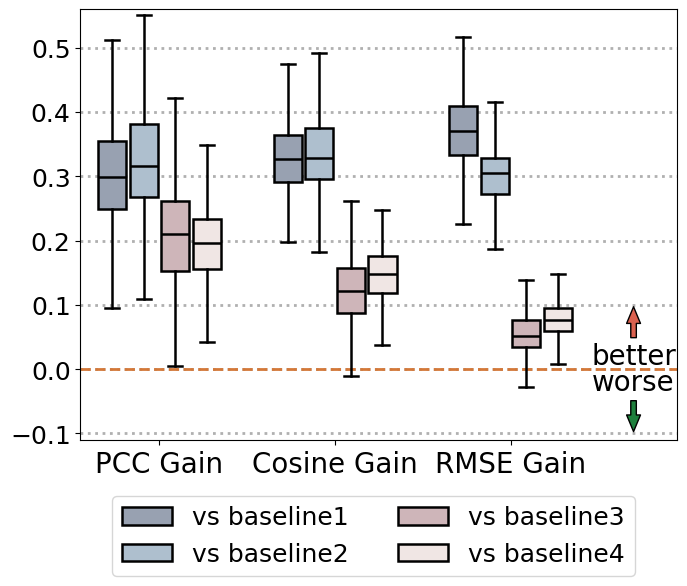

In [ ]:
# Fig. 2a
fig, ax = plt.subplots(figsize=(7, 6))

centers = np.array([1, 2, 3])
offsets = np.array([-0.27, -0.09, 0.09, 0.27])
palette = ['#98a1b1', '#aebfce', '#ceb5b9', '#f0e6e4']
common = dict(widths=0.16, zorder=10, notch=False, vert=True, patch_artist=True,
              whiskerprops=dict(color='black', linestyle='-', linewidth=1.8),
              capprops=dict(color='black', linewidth=1.8), showfliers=False)

box_handles = []
for off, color, data in zip(offsets, palette, gains_per_baseline):
    bp = ax.boxplot(data, positions=centers + off,
                    boxprops=dict(facecolor=color, linewidth=1.8),
                    medianprops=dict(linewidth=1.8, color='black'), **common)
    box_handles.append(bp['boxes'][0])

ax.axhline(0, color='#d47838', linestyle='--', linewidth=2)
ax.annotate('better', xy=(3.7, 0.1), xytext=(3.7, 0.02), fontsize=20, ha='center', va='center',
            arrowprops=dict(facecolor='#db614f', shrink=0.05, width=4, headwidth=10))
ax.annotate('worse', xy=(3.7, -0.1), xytext=(3.7, -0.02), fontsize=20, ha='center', va='center',
            arrowprops=dict(facecolor='#1e803d', shrink=0.05, width=4, headwidth=10))

ax.set_xticks(centers)
ax.set_xticklabels(['PCC Gain', 'Cosine Gain', 'RMSE Gain'], fontsize=20)
ax.tick_params(axis='y', labelsize=18)
ax.set_xlim(0.55, 3.95)
ax.set_ylim(-0.11, 0.56)
ax.set_yticks(np.arange(-0.1, 0.6, 0.1))
ax.grid(axis='y', linestyle=':', linewidth=2)
ax.legend(box_handles, ['vs baseline1', 'vs baseline2', 'vs baseline3', 'vs baseline4'],
          ncol=2, fontsize=18, bbox_to_anchor=(0.95, -0.1))

plt.tight_layout()
plt.show()

## Fig. 2b — SVC-predicted relative distance to the nuclear center for 49 genes with well-annotated subcellular localization patterns, against the truth values

Dot colors indicate different types of subcellular patterns.

In [3]:
# the 49 genes annotated in seqFISH+ extended data fig 3
protrusion_genes = ['Cyb5r3', 'Sh3pxd2a', 'Ddr2', 'Kif1c', 'Kctd10',
                    'Dynll2', 'Arhgap11a', 'Dync1li2', 'Palld', 'Naa50']
nuclear_genes = ['Col1a1', 'Fn1', 'Fbln2', 'Col6a2', 'Bgn',
                 'Nid1', 'Lox', 'P4hb', 'Aebp1', 'Emp1',
                 'Col5a1', 'Sdc4', 'Postn', 'Col3a1', 'Pdia6',
                 'Col5a2', 'Itgb1', 'Calu', 'Pdia3']
cytoplasm_genes = ['Ddb1', 'Myh9', 'Actn1', 'Tagln2', 'Kpnb1',
                   'Hnrnpf', 'Ppp1ca', 'Hnrnpl', 'Pcbp1', 'Tagln',
                   'Fscn1', 'Psat1', 'Cald1', 'Snd1', 'Uba1',
                   'Hnrnpm', 'Cap1', 'Ssrp1', 'Ugdh', 'Caprin1']

selected_gene = protrusion_genes + nuclear_genes + cytoplasm_genes
selected_gene_idx = [gene_names.index(g) for g in selected_gene]
gene_type = np.array(['Protrusion' if g in protrusion_genes else
                      'Cytoplasm' if g in cytoplasm_genes else 'Nuclear/Perinuclear'
                      for g in selected_gene])

# distance of each pixel to the grid center, in units of the half-grid
_ii, _jj = np.meshgrid(np.arange(12), np.arange(12), indexing='ij')
D = np.sqrt((_ii + 0.5 - 6) ** 2 + (_jj + 0.5 - 6) ** 2) / 6


def distance_ratio(img):
    """Count-weighted mean distance to the grid center, per (cell, gene), capped at 1."""
    total = img.sum(axis=(-1, -2))
    r = np.where(total != 0, (img * D).sum(axis=(-1, -2)) / np.where(total == 0, 1, total), 0.0)
    return np.where(total != 0, np.minimum(r, 1.0), 0.0)


MIN_COUNTS = 5
counts_49 = truth_test[:, selected_gene_idx].sum(axis=(-1, -2))
valid_49 = counts_49 >= MIN_COUNTS
print('(cell, gene) images kept: %d / %d' % (valid_49.sum(), valid_49.size))

real_ratio = distance_ratio(truth_test[:, selected_gene_idx])    # (n_cells, 49)
pred_ratio = distance_ratio(prediction[:, selected_gene_idx])
real_dist = (real_ratio * valid_49).sum(0) / valid_49.sum(0)
pred_dist = (pred_ratio * valid_49).sum(0) / valid_49.sum(0)

(cell, gene) images kept: 671 / 686


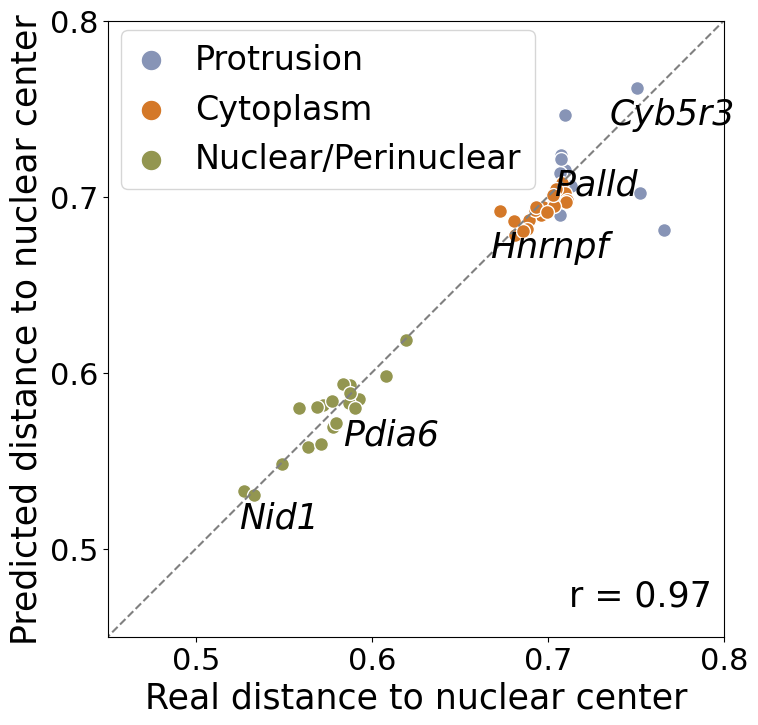

In [4]:
# Fig. 2b
representative_genes = ['Nid1', 'Pdia6', 'Hnrnpf', 'Palld', 'Cyb5r3']
custom_colors = ['#8794b6', '#d47828', '#939650']

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
for color, atype in zip(custom_colors, ['Protrusion', 'Cytoplasm', 'Nuclear/Perinuclear']):
    s = gene_type == atype
    ax.scatter(real_dist[s], pred_dist[s], c=color, s=100, label=atype, edgecolor='white')

ax.legend(title='', fontsize=24, bbox_to_anchor=(0.72, 0.7), markerscale=1.5, handlelength=1)
ax.text(0.98, 0.05, f'r = {np.corrcoef(real_dist, pred_dist)[0, 1]:.2f}',
        transform=ax.transAxes, ha='right', fontsize=25)
for gene in representative_genes:
    k = selected_gene.index(gene)
    ax.annotate(gene, (real_dist[k] + 0.02, pred_dist[k] - 0.001), textcoords='offset points',
                xytext=(0, -25), ha='center', fontsize=25, fontstyle='italic')

ax.plot([0, 0.8], [0, 0.8], '--', color='gray')
ax.set_aspect('equal')
ax.set_xlim(0.45, 0.8)
ax.set_ylim(0.45, 0.8)
ax.set_xticks([0.5, 0.6, 0.7, 0.8])
ax.set_xticklabels([0.5, 0.6, 0.7, 0.8], fontsize=22)
ax.set_yticks([0.5, 0.6, 0.7, 0.8])
ax.set_yticklabels([0.5, 0.6, 0.7, 0.8], fontsize=22)
ax.set_xlabel('Real distance to nuclear center', fontsize=25)
ax.set_ylabel('Predicted distance to nuclear center', fontsize=25)

plt.show()

## Fig. 2c — SVC-predicted transcript profiles within the original cells alongside the ground truth, for five representative genes

Predicted transcripts are sampled from `prediction_mu.npz` and `prediction_r.npz` on a 48x48
grid and mapped back onto each cell's own contour.

In [ ]:
from svc.postprocess import (expand_transcripts, postprocess_predictions,
                             postprocess_predictions_original, postprocess_sampling)

test_cell_names = np.load(DATA_DIR / 'test_seqfish.npz', allow_pickle=True)['cell_names']
df_cell_contour = pd.read_pickle(DATA_DIR / 'cell_mask_contour_preprocessed.pkl')
df_nuclear_contour = pd.read_pickle(DATA_DIR / 'nuclear_mask_contour_preprocessed.pkl')
prediction_r = np.load(HERE / 'precomputed/prediction_r.npz')['prediction']

count_data = postprocess_sampling(prediction[:, selected_gene_idx],
                                  prediction_r[:, selected_gene_idx], 2026)
pred_tx = postprocess_predictions(count_data, selected_gene, test_cell_names)
pred_tx = postprocess_predictions_original(pred_tx, df_cell_contour)
pred_tx = expand_transcripts(pred_tx)                         # one row per transcript
print('predicted transcripts:', len(pred_tx))

predicted transcripts: 40138


In [ ]:
# measured transcripts and outlines: the 14 test cells for Fig. 2c, field of view 0 for Fig. 2j.
# The 1 GB transcript table is read once here and sliced for both.
_data = pd.read_pickle(DATA_DIR / 'seqfish_data_dict.pkl')       # ~1 GB, ~20 s
_tx = _data['data_df'][['x', 'y', 'gene', 'cell']]
del _data

_test_cells = set(test_cell_names)
measured_tx = _tx[_tx.cell.isin(_test_cells)]
cell_contour = df_cell_contour[df_cell_contour.cell.isin(_test_cells)]
nuclear_contour = df_nuclear_contour[df_nuclear_contour.cell.isin(_test_cells)]

FOV = '0'
_in_fov = lambda names: np.array([c.split('-')[1] == FOV for c in names])
fov_tx = _tx[_in_fov(_tx.cell)]
fov_cell_contour = df_cell_contour[_in_fov(df_cell_contour.cell)]
fov_nuclear_contour = df_nuclear_contour[_in_fov(df_nuclear_contour.cell)]
del _tx

print('test cells: %d transcripts | field of view %s: %d cells, %d transcripts'
      % (len(measured_tx), FOV, fov_cell_contour.cell.nunique(), len(fov_tx)))

test cells: 342829 transcripts | field of view 0: 13 cells, 362961 transcripts


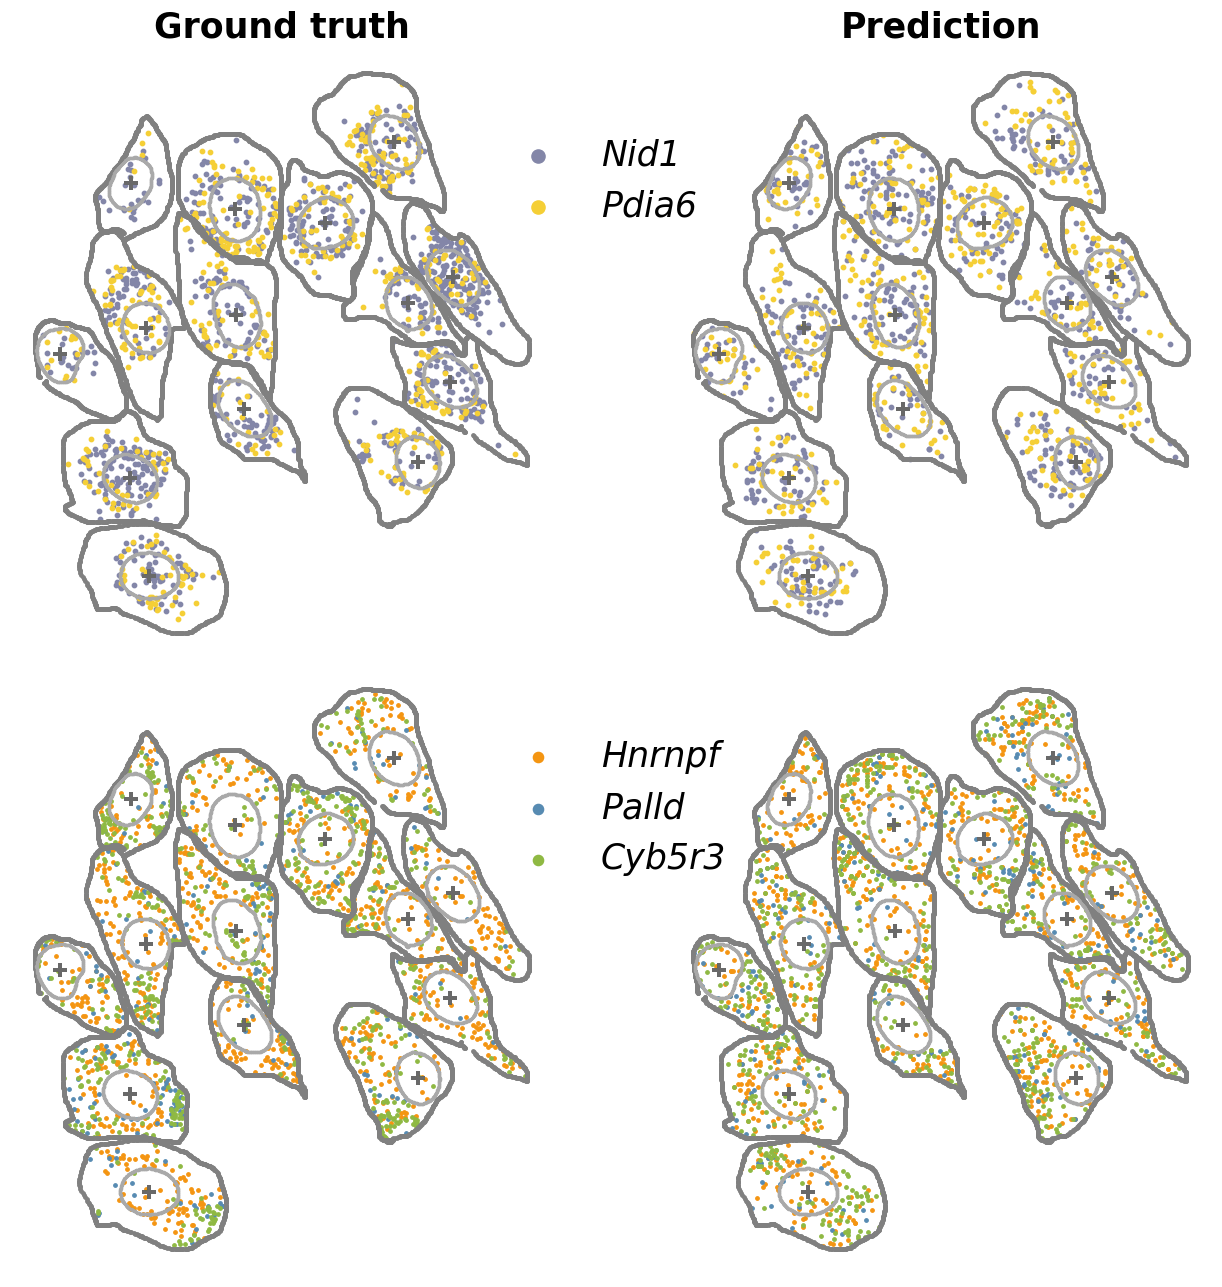

In [ ]:
# Fig. 2c
def transcript_panel(ax, tx, genes, colors, x_col, y_col, size):
    ax.scatter(cell_contour.x, cell_contour.y, color='grey', s=6, zorder=20)
    ax.scatter(nuclear_contour.x, nuclear_contour.y, alpha=0.6, s=2, color='darkgrey', zorder=20)
    ax.scatter(nuclear_contour['centerX'], nuclear_contour['centerY'],
               marker='+', color='dimgray', s=100, zorder=20)
    for g, c in zip(genes, colors):
        sub = tx[tx['gene'] == g]
        ax.scatter(sub[x_col], sub[y_col], s=size, color=c, label=g)
    ax.set_aspect('equal')
    ax.axis('off')

top_genes, top_colors = ['Nid1', 'Pdia6'], ['#8386a8', '#f5cf36']
bottom_genes, bottom_colors = ['Hnrnpf', 'Palld', 'Cyb5r3'], ['#f49512', '#578bb2', '#8fb943']

fig, ax = plt.subplots(2, 2, figsize=(17, 16), gridspec_kw={'hspace': 0., 'wspace': 0})
transcript_panel(ax[0, 0], measured_tx, top_genes, top_colors, 'x', 'y', 10)
transcript_panel(ax[0, 1], pred_tx, top_genes, top_colors, 'x_original', 'y_original', 10)
transcript_panel(ax[1, 0], measured_tx, bottom_genes, bottom_colors, 'x', 'y', 6)
transcript_panel(ax[1, 1], pred_tx, bottom_genes, bottom_colors, 'x_original', 'y_original', 6)

ax[0, 0].set_title('Ground truth', fontsize=25, fontweight='bold')
ax[0, 1].set_title('Prediction', fontsize=25, fontweight='bold')
for a, anchor in [(ax[0, 0], (0.85, 0.9)), (ax[1, 0], (0.85, 0.6))]:
    leg = a.legend(fontsize=25, markerscale=3, bbox_to_anchor=anchor, frameon=False)
    for t in leg.get_texts():
        t.set_fontstyle('italic')

plt.show()

## Fig. 2d — distributions of SVC-predicted relative distance to the nuclear center and the corresponding ground-truth values across cells, for the five genes

P values from two-sided Wilcoxon signed-rank tests.

In [5]:
rows, pvals = [], {}
for g in representative_genes:
    k = selected_gene.index(g)
    v = valid_49[:, k]
    pvals[g] = wilcoxon(pred_ratio[v, k], real_ratio[v, k], alternative='two-sided')[1]
    rows.append(pd.DataFrame({
        'Group': g,
        'Subgroup': np.repeat(['Prediction', 'Ground truth'], v.sum()),
        'Value': np.concatenate([pred_ratio[v, k], real_ratio[v, k]]),
    }))
df = pd.concat(rows, ignore_index=True)

for g in representative_genes:
    print('%-8s cells %2d/%d  p = %.4f' % (g, valid_49[:, selected_gene.index(g)].sum(), n_cells, pvals[g]))

Nid1     cells 14/14  p = 0.6698
Pdia6    cells 14/14  p = 0.3258
Hnrnpf   cells 14/14  p = 0.4631
Palld    cells 14/14  p = 0.6698
Cyb5r3   cells 14/14  p = 0.6257


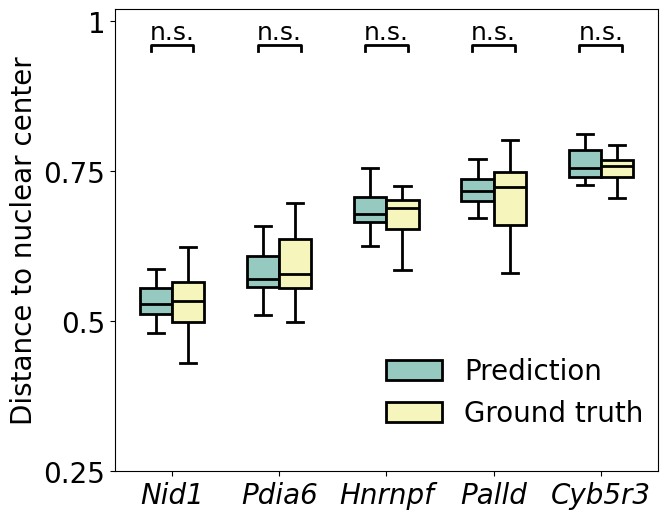

In [8]:
# Fig. 2d
def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
sns.boxplot(data=df, x='Group', y='Value', hue='Subgroup',
            order=representative_genes, hue_order=['Prediction', 'Ground truth'], linecolor='black',
            palette=['#8dd3c7', '#ffffb3'], width=0.6, linewidth=2, showfliers=False, ax=ax)

y_max, y_offset_inter = 1, 0.05
for i, g in enumerate(representative_genes):
    ax.plot([i - 0.2, i - 0.2, i + 0.2, i + 0.2],
            [y_max - y_offset_inter, y_max - y_offset_inter + 0.01,
             y_max - y_offset_inter + 0.01, y_max - y_offset_inter],
            color='black', lw=2, clip_on=False)
    ax.text(i, y_max - y_offset_inter + 0.02, stars(pvals[g]), size=18, ha='center')

ax.set_ylim(0.25, 1.02)
ax.legend(title='', fontsize=20, bbox_to_anchor=(1.02, 0.3), frameon=False)
ax.set_xlabel('')
ax.set_xticks(range(len(representative_genes)))
ax.set_xticklabels(representative_genes, fontsize=20, fontstyle='italic')
ax.set_ylabel('Distance to nuclear center', fontsize=20)
ax.set_yticks([0.25, 0.5, 0.75, 1])
ax.set_yticklabels([0.25, 0.5, 0.75, 1], fontsize=20)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

plt.show()

## Fig. 2e — subcellular prediction accuracy versus expression level and latent-space neighborhood similarity

The color scale is the average distance to the 10 nearest neighbors (10-NN) in latent space,
computed from `precomputed/latent_test.npz`.

In [13]:
K_NN = 10
latent = np.load(HERE / 'precomputed/latent_test.npz')['emb'].astype(np.float32)  # (n_cells, n_genes, 384)
_counts = truth_test.sum(axis=(-1, -2))
_acc = np.zeros(n_genes)
_n_valid = np.zeros(n_genes)

for c in range(n_cells):
    d = np.sort(cdist(latent[c], latent[c], metric='cosine'), axis=1)[:, 1:K_NN + 1].mean(1)
    valid = _counts[c] >= MIN_COUNTS
    _acc[valid] += d[valid]
    _n_valid[valid] += 1

knn_dist = _acc / _n_valid
expr_level = np.log1p(_counts.mean(0))
print('10-NN distance %.3f - %.3f | spearman with spatial PCC %.3f'
      % (knn_dist.min(), knn_dist.max(),
         np.corrcoef(np.argsort(np.argsort(knn_dist)), np.argsort(np.argsort(pcc_svc)))[0, 1]))

10-NN distance 0.179 - 0.521 | spearman with spatial PCC -0.911


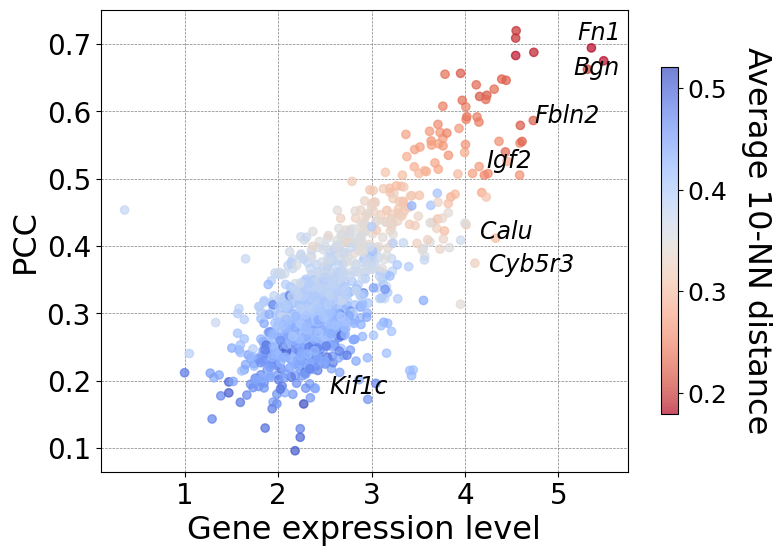

In [14]:
# Fig. 2e
labelled_genes = {'Fn1': (-10, 6), 'Bgn': (-10, -4), 'Fbln2': (10, 2), 'Igf2': (10, 4),
                  'Calu': (10, -10), 'Cyb5r3': (10, -6), 'Kif1c': (10, -4)}

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.set_axisbelow(True)
ax.grid(linestyle='--', linewidth=0.5, color='gray')
sc = ax.scatter(expr_level, pcc_svc, alpha=0.7, c=knn_dist, cmap='coolwarm_r')

for gene, offset in labelled_genes.items():
    i = gene_names.index(gene)
    ax.annotate(gene, (expr_level[i], pcc_svc[i]), textcoords='offset points', xytext=offset,
                ha='left', fontsize=17, fontstyle='italic')

cbar = fig.colorbar(sc, shrink=0.75)
cbar.ax.tick_params(labelsize=18)
cbar.set_label('Average 10-NN distance', fontsize=23, rotation=270, labelpad=32)

ax.tick_params(labelsize=20)
ax.set_xlabel('Gene expression level', fontsize=23)
ax.set_ylabel('PCC', fontsize=23)

plt.show()

## Fig. 2f — cell-level gene expression prediction: log1p-transformed average RMSE and PCC across genes from 20-fold cross-validation, SVC compared with uniPort, ENVI, Tangram and gimVI

Cell-level predictions of the four compared methods are in `precomputed/`; the SVC
values are the pixel sum of `prediction_mu.npz`.

In [16]:
METHODS = ['uniPort', 'ENVI', 'Tangram', 'gimVI', 'SVC']

cell_counts_pred = {m: np.load(HERE / f'precomputed/{m}_cell_gene_predictions.npy')
                    for m in METHODS if m != 'SVC'}
cell_counts_pred['SVC'] = prediction.sum(axis=(-1, -2))
cell_counts_true = truth_test.sum(axis=(-1, -2))                  # (n_cells, n_genes)

rmse_gene = {m: np.sqrt(np.mean((cell_counts_true - p) ** 2, axis=0))
             for m, p in cell_counts_pred.items()}


def pcc_gene(pred, truth):
    """Per-gene PCC across cells, over cells with a non-zero measured count."""
    pcc = np.full(truth.shape[1], np.nan)
    for i in range(truth.shape[1]):
        nz = truth[:, i] != 0
        if nz.sum() > 1:
            pcc[i] = np.corrcoef(pred[nz, i], truth[nz, i])[0, 1]
    return pcc


pcc_gene_ = {m: pcc_gene(np.asarray(p, dtype=np.float64), cell_counts_true.astype(np.float64))
             for m, p in cell_counts_pred.items()}

for m in METHODS:
    print('%-8s median RMSE %.4f   median PCC %.4f' % (m, np.median(rmse_gene[m]), np.nanmedian(pcc_gene_[m])))

uniPort  median RMSE 6.3254   median PCC 0.4484
ENVI     median RMSE 6.4687   median PCC 0.4310
Tangram  median RMSE 5.6399   median PCC 0.4158
gimVI    median RMSE 5.6607   median PCC 0.4683
SVC      median RMSE 5.1177   median PCC 0.4979


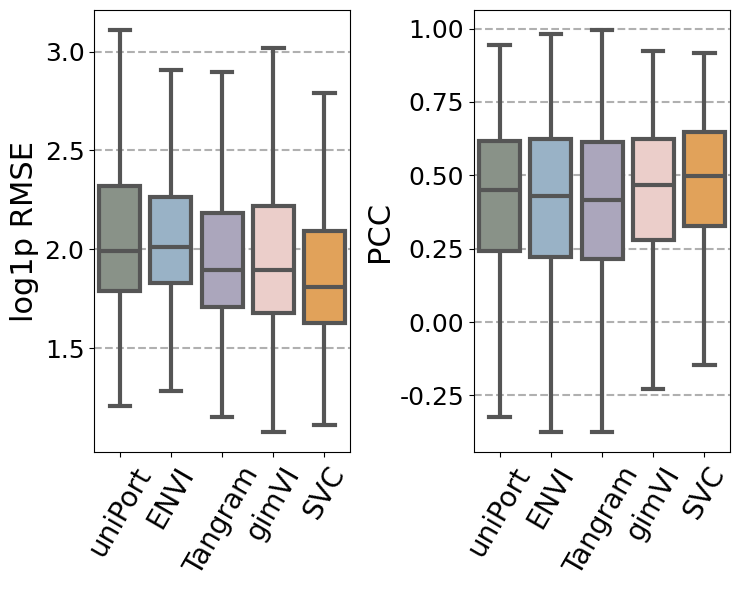

In [17]:
# Fig. 2f
colors = ['#879486', '#91b3ce', '#A9A3BF', '#f1cac4', '#f7a444']

fig, ax = plt.subplots(1, 2, figsize=(7.5, 6), gridspec_kw={'width_ratios': [1, 1]})

sns.boxplot([np.log1p(rmse_gene[m]) for m in METHODS],
            ax=ax[0], palette=colors, zorder=2, showfliers=False, linewidth=3)
ax[0].set_ylabel('log1p RMSE', fontsize=22)
ax[0].set_yticks(np.arange(1.5, 3.1, 0.5))
ax[0].set_yticklabels(['1.5', '2.0', '2.5', '3.0'], fontsize=18)

sns.boxplot([pcc_gene_[m] for m in METHODS],
            ax=ax[1], palette=colors, zorder=2, showfliers=False, linewidth=3)
ax[1].set_ylabel('PCC', fontsize=22)
ax[1].set_yticks(np.arange(-0.25, 1.01, 0.25))
ax[1].set_yticklabels(['-0.25', '0.00', '0.25', '0.50', '0.75', '1.00'], fontsize=18)

for a in ax:
    a.set_xticks(range(len(METHODS)))
    a.set_xticklabels(METHODS, fontsize=20, rotation=60)
    a.grid(axis='y', linestyle='--', linewidth=1.5)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

## Fig. 2g — SVC-predicted versus observed cell-level expression across all genes, on a log-transformed scale

Pearson correlation is calculated on the original scale.

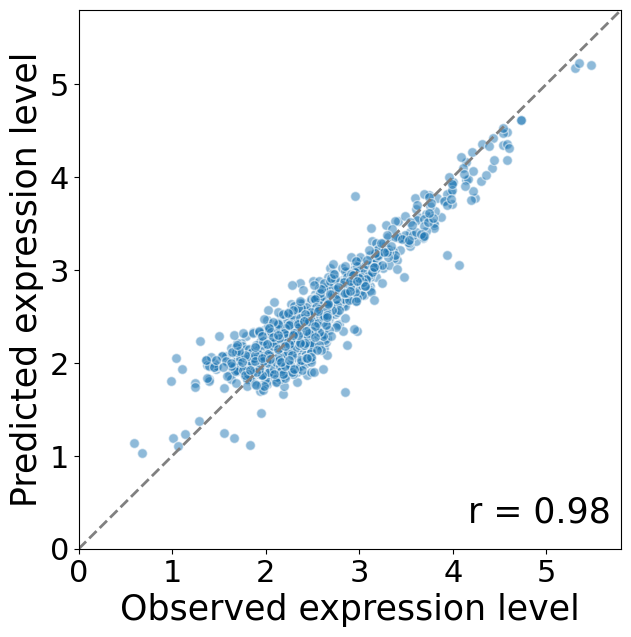

In [18]:
# Fig. 2g
obs_level = cell_counts_true.mean(0)
pred_level = cell_counts_pred['SVC'].mean(0)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
ax.scatter(np.log(obs_level + 0.1), np.log(pred_level + 0.1), s=50, alpha=0.5, edgecolors='white')
ax.plot([0, 6], [0, 6], '--', lw=2, color='gray')
ax.set_xlim(0, 5.8)
ax.set_ylim(0, 5.8)
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_xticklabels([0, 1, 2, 3, 4, 5], fontsize=22)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels([0, 1, 2, 3, 4, 5], fontsize=22)
ax.set_xlabel('Observed expression level', fontsize=25)
ax.set_ylabel('Predicted expression level', fontsize=25)
ax.text(0.98, 0.05, f'r = {np.corrcoef(obs_level, pred_level)[0, 1]:.2f}',
        transform=ax.transAxes, ha='right', fontsize=25)
# ax.set_title('SVC', fontsize=25)

plt.show()

## Fig. 2h — top 50, 100, 200, 500 and 1000 co-localized gene pairs detected by SVC and InSTAnT

Per-cell 10-NN counts over the 157 training cells are in
`precomputed/svc_knn_coloc_counts.npz`; the InSTAnT ranking is
`precomputed/instant_top1000_pairs.csv`.

In [19]:
TOP_N = [50, 100, 200, 500, 1000]
DETECT = 1

# Gene co-localization score (Methods), from the staged per-cell 10-NN counts.
counts_train = np.load(HERE / 'precomputed/svc_knn_coloc_counts.npz', allow_pickle=True)
n_valid_train = (truth_train.sum(axis=(-1, -2)) >= DETECT).sum(0)
coloc = counts_train['counts'].astype(np.float64) / n_valid_train[:, None]
coloc = np.maximum(coloc, coloc.T)
train_genes = counts_train['genes']

upper = np.triu(coloc)
svc_pairs = []
for _ in range(max(TOP_N)):
    i, j = np.unravel_index(np.argmax(upper), upper.shape)
    svc_pairs.append((train_genes[i], train_genes[j]))
    upper[i, j] = 0

instant_pairs = [tuple(r) for r in
                 pd.read_csv(HERE / 'precomputed/instant_top1000_pairs.csv')
                 [['gene_id1', 'gene_id2']].values]


def same_compartment(pair):
    """A pair is verified when both genes carry the same subcellular annotation."""
    a, b = pair
    return any(a in group and b in group
               for group in (protrusion_genes, nuclear_genes, cytoplasm_genes))


overlap, svc_verified, instant_verified = [], [], []
for n in TOP_N:
    svc_n, instant_n = svc_pairs[:n], instant_pairs[:n]
    common = [p for p in svc_n if p in instant_n or (p[1], p[0]) in instant_n]
    svc_only = [p for p in svc_n if p not in common]
    instant_only = [p for p in instant_n if p not in svc_n and (p[1], p[0]) not in svc_n]
    overlap.append(len(common))
    svc_verified.append(sum(map(same_compartment, svc_only)))
    instant_verified.append(sum(map(same_compartment, instant_only)))
    print('top %4d  overlap %3d | verified SVC-specific %3d | verified InSTAnT-specific %3d'
          % (n, len(common), svc_verified[-1], instant_verified[-1]))

top   50  overlap  28 | verified SVC-specific  16 | verified InSTAnT-specific  10
top  100  overlap  64 | verified SVC-specific  28 | verified InSTAnT-specific  16
top  200  overlap 122 | verified SVC-specific  54 | verified InSTAnT-specific  20
top  500  overlap 220 | verified SVC-specific 113 | verified InSTAnT-specific  39
top 1000  overlap 401 | verified SVC-specific 158 | verified InSTAnT-specific  36


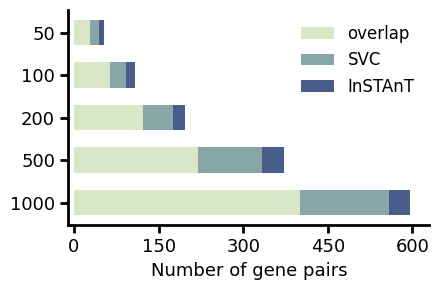

In [20]:
# Fig. 2h
fig, ax = plt.subplots(figsize=(4.5, 3))
y = np.arange(len(TOP_N))
d1, d2, d3 = np.array(overlap), np.array(svc_verified), np.array(instant_verified)

ax.barh(y, d1, color='#DAE7C6', height=0.6, label='overlap')
ax.barh(y, d2, left=d1, color='#88A6A8', height=0.6, label='SVC')
ax.barh(y, d3, left=d1 + d2, color='#485D8A', height=0.6, label='InSTAnT')

ax.invert_yaxis()
ax.set_yticks(y)
ax.set_yticklabels([str(n) for n in TOP_N], fontsize=13)
ax.set_xticks([0, 150, 300, 450, 600])
ax.set_xticklabels([0, 150, 300, 450, 600], fontsize=13)
ax.tick_params(axis='both', which='major', width=2, length=6)
ax.set_xlabel('Number of gene pairs', fontsize=13)
ax.set_xlim(-10, 630)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.show()

## Fig. 2i — subcellular co-localization scores for pairs of the 49 genes

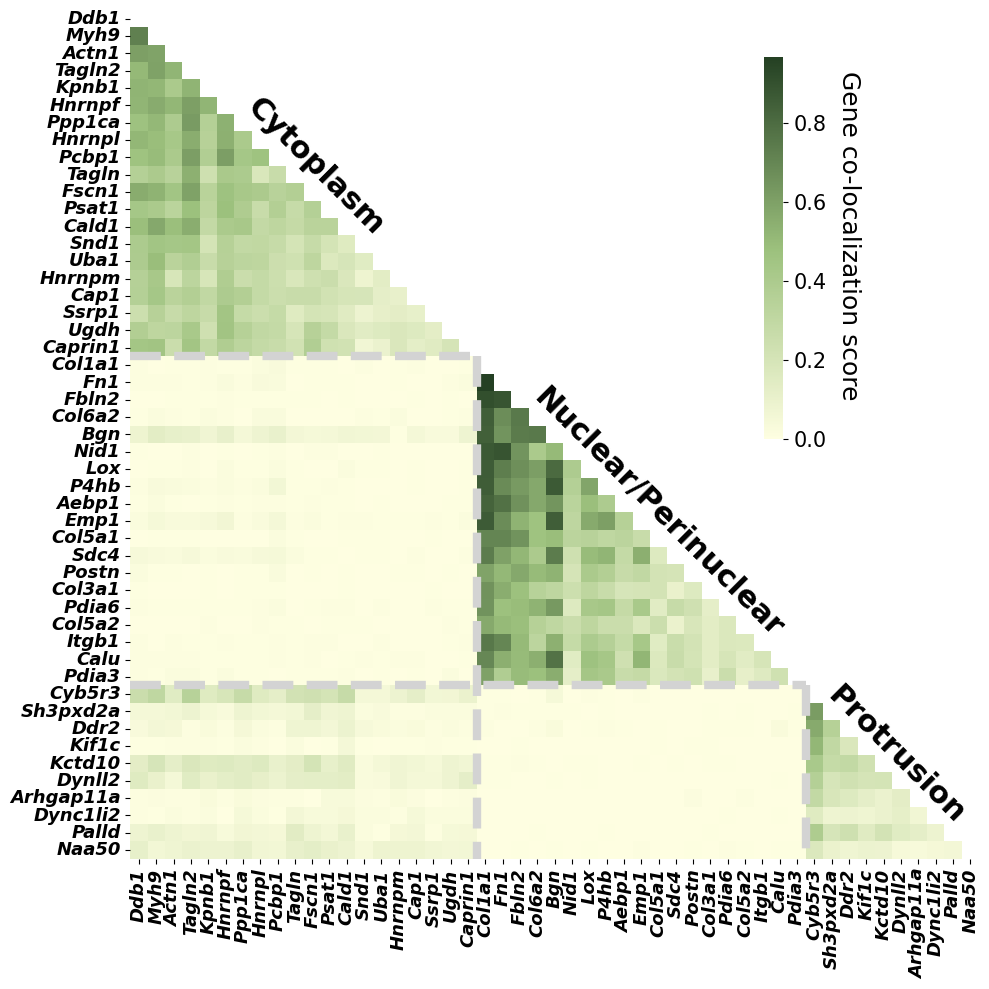

In [21]:
# Fig. 2i
from matplotlib.colors import LinearSegmentedColormap

heatmap_genes = cytoplasm_genes + nuclear_genes + protrusion_genes
_k = [gene_names.index(g) for g in heatmap_genes]
coloc_49 = coloc[np.ix_(_k, _k)]

cmap = LinearSegmentedColormap.from_list('coloc', ['#FEFEE1', '#9bc07c', '#244023'])
n_cyto, n_nuc = len(cytoplasm_genes), len(cytoplasm_genes) + len(nuclear_genes)

fig, ax = plt.subplots(figsize=(15, 10))
hm = sns.heatmap(coloc_49, cmap=cmap, mask=np.triu(np.ones_like(coloc_49, dtype=bool)),
                 xticklabels=heatmap_genes, yticklabels=heatmap_genes, square=True,
                 cbar_kws={'shrink': 0.45, 'pad': -0.05, 'anchor': (-0.7, 0.9), 'location': 'right'})
hm.set_xticklabels(hm.get_xticklabels(), fontweight='bold', fontsize=13, fontstyle='italic')
hm.set_yticklabels(hm.get_xticklabels(), fontweight='bold', fontsize=13, fontstyle='italic')

cbar = hm.collections[0].colorbar
cbar.ax.set_position([1, 0.1, 0.9, 0.2])
cbar.ax.tick_params(labelsize=15)
cbar.set_label('Gene co-localization score', rotation=270, fontsize=18, loc='top', labelpad=25)
cbar.ax.get_yaxis().get_label().set_position((-0.3, 0.1))

# dashed frames around the three annotation blocks
ax.plot([0, n_cyto], [n_cyto, n_cyto], color='lightgray', linestyle='--', linewidth=6)
ax.plot([0, n_nuc], [n_nuc, n_nuc], color='lightgray', linestyle='--', linewidth=6)
ax.plot([n_cyto, n_cyto], [n_cyto, len(heatmap_genes)], color='lightgray', linestyle='--', linewidth=6)
ax.plot([n_nuc, n_nuc], [n_nuc, len(heatmap_genes)], color='lightgray', linestyle='--', linewidth=6)

for x, y, label in [(15, 9, 'Cytoplasm'), (38, 29, 'Nuclear/Perinuclear'), (48.5, 43, 'Protrusion')]:
    ax.text(x, y, label, va='center', ha='right', color='black',
            fontsize=22, fontweight='bold', rotation=315)

plt.tight_layout()
plt.show()

## Fig. 2j — observed transcript profiles within original cells for three representative co-localization gene pairs

In [22]:
COMPARTMENTS = [('Cytoplasm', cytoplasm_genes),
                ('Nuclear/Perinuclear', nuclear_genes),
                ('Protrusion', protrusion_genes)]

top_pair = {}
for name, group in COMPARTMENTS:
    k = [gene_names.index(g) for g in group]
    block = np.triu(coloc[np.ix_(k, k)], 1)
    ranked = []
    for _ in range(3):
        i, j = np.unravel_index(np.argmax(block), block.shape)
        ranked.append((group[i], group[j], block[i, j]))
        block[i, j] = 0
    top_pair[name] = ranked[0][:2]
    print('%-20s %s' % (name, '   '.join('%s+%s %.3f' % r for r in ranked)))

Cytoplasm            Ddb1+Myh9 0.724   Tagln2+Ppp1ca 0.623   Tagln2+Pcbp1 0.611
Nuclear/Perinuclear  Col1a1+Fn1 0.968   Col1a1+Fbln2 0.910   Fn1+Nid1 0.892
Protrusion           Cyb5r3+Sh3pxd2a 0.619   Cyb5r3+Ddr2 0.565   Cyb5r3+Kif1c 0.515


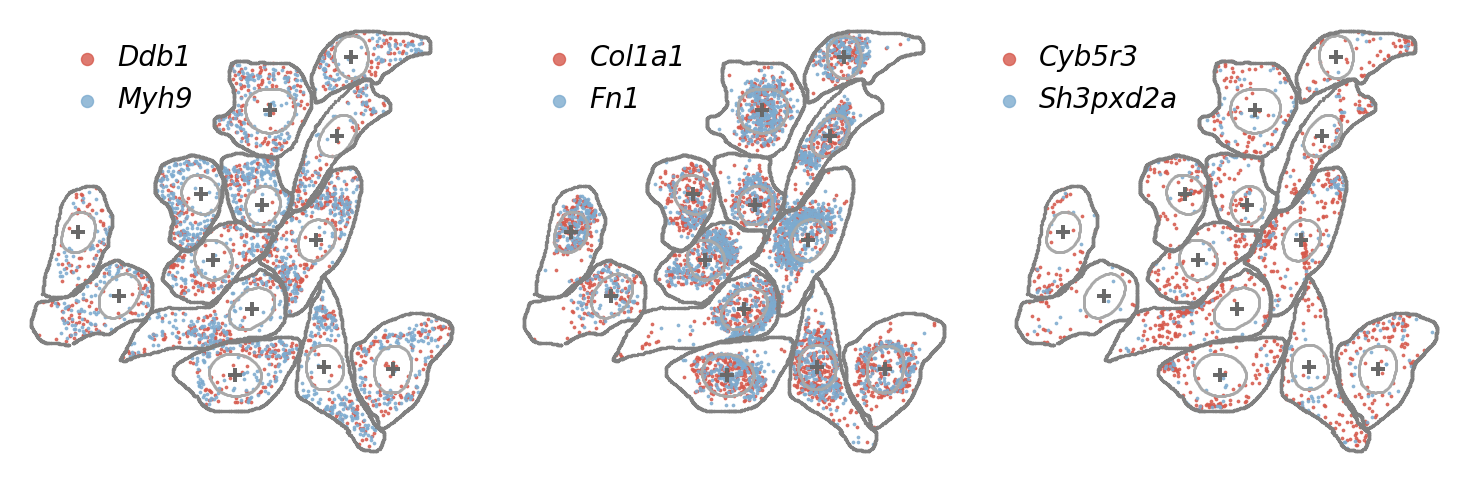

In [23]:
# Fig. 2j
fig, ax = plt.subplots(1, 3, figsize=(19, 6), gridspec_kw={'hspace': 0., 'wspace': 0.01})

for a, (name, _) in zip(ax, COMPARTMENTS):
    for gene, color in zip(top_pair[name], ['#d6594c', '#7dabcf']):
        sub = fov_tx[fov_tx.gene == gene]
        a.scatter(sub['x'], sub['y'], label=gene, alpha=0.8, s=3, color=color)
    a.scatter(fov_nuclear_contour['x'], fov_nuclear_contour['y'], alpha=0.6, s=0.5, color='darkgrey')
    a.scatter(fov_cell_contour['x'], fov_cell_contour['y'], color='grey', s=2)
    a.scatter(fov_cell_contour['centerX'], fov_cell_contour['centerY'],
              marker='+', color='dimgray', s=100)
    a.set_aspect('equal')
    a.axis('off')
    leg = a.legend(fontsize=20, markerscale=5, bbox_to_anchor=(0.45, 0.72),
                   frameon=False, handletextpad=0.1)
    for t in leg.get_texts():
        t.set_fontstyle('italic')

plt.show()

## Fig. 2k — UMAP of the 49 genes, obtained from the average latent representation of each gene across training cells

UMAP here is sensitive to the float16 storage of the latent representations, so the layout
differs from the published panel while the three annotation groups separate the same way.

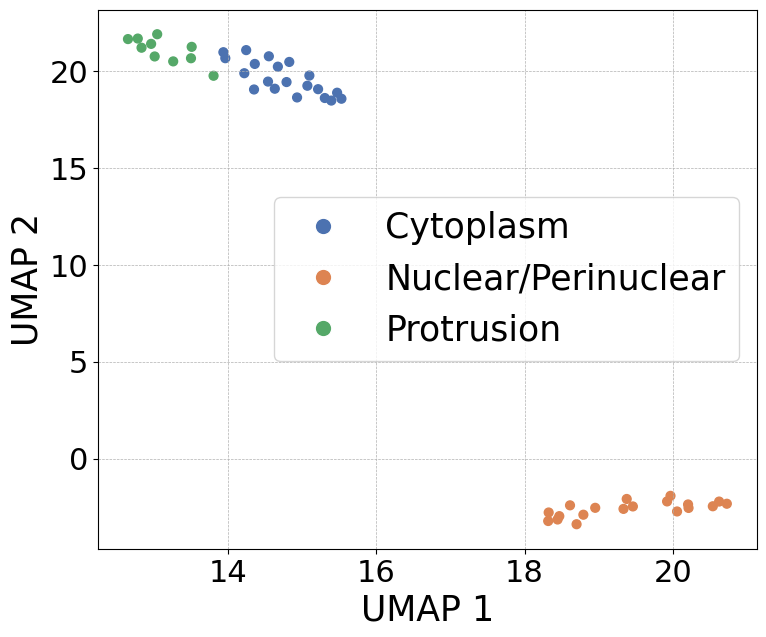

In [24]:
# Fig. 2k
import umap
from matplotlib.colors import ListedColormap

_z = np.load(HERE / 'precomputed/latent_train_mean_49genes.npz', allow_pickle=True)
umap_genes = list(_z['genes'])                      # cytoplasm, then nuclear, then protrusion
reducer = umap.UMAP()
reducer.set_params(random_state=1234)
coords = reducer.fit_transform(_z['emb'])

group = [0 if g in cytoplasm_genes else 1 if g in nuclear_genes else 2 for g in umap_genes]
cmap = ListedColormap(['#4C72B0', '#DD8452', '#55A868'])

fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(coords[:, 1], coords[:, 0], s=40, c=group, cmap=cmap)
ax.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=label,
                              markerfacecolor=cmap(i), markersize=12)
                   for i, label in enumerate(['Cytoplasm', 'Nuclear/Perinuclear', 'Protrusion'])],
          fontsize=25, loc='best')
ax.set_xlabel('UMAP 1', fontsize=25)
ax.set_ylabel('UMAP 2', fontsize=25)
ax.tick_params(labelsize=22)
ax.grid(True, linestyle='--', linewidth=0.5)

plt.show()

Cosine distances between cluster-average representations in the learned latent space (main text, Results).

In [25]:
# Fig. 2k - distance between the three compartments in the latent space
def cosine_distance(x, y, eps=1e-12):
    return 1.0 - np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y) + eps)


_row = {g: i for i, g in enumerate(umap_genes)}
compartment_mean = {name: _z['emb'][[_row[g] for g in group]].mean(0)
                    for name, group in [('nuclear', nuclear_genes),
                                        ('cytoplasm', cytoplasm_genes),
                                        ('protrusion', protrusion_genes)]}
for a, b in [('nuclear', 'cytoplasm'), ('nuclear', 'protrusion'), ('cytoplasm', 'protrusion')]:
    print('%-24s %.4f' % ('%s - %s' % (a, b),
                          cosine_distance(compartment_mean[a], compartment_mean[b])))

nuclear - cytoplasm      0.1266
nuclear - protrusion     0.3460
cytoplasm - protrusion   0.1811


## Fig. 2l — co-localization scores for cytoplasmic-localized, nuclear/perinuclear-localized and protrusion-related genes, averaged across cells in G1, S and G2/M phase

P values from one-sided Wilcoxon signed-rank tests.

In [26]:
PHASES = ['G1', 'S', 'G2/M']
# comparisons drawn per panel, each in the direction being claimed
PHASE_TESTS = {'Cytoplasm': [('G2/M', 'G1'), ('G2/M', 'S')],
               'Nuclear/Perinuclear': [('G1', 'G2/M'), ('S', 'G2/M')],
               'Protrusion': [('G1', 'S'), ('G1', 'G2/M')]}

_p = np.load(HERE / 'precomputed/svc_knn_coloc_counts_by_phase.npz', allow_pickle=True)
coloc_phase = _p['counts'].astype(np.float64) / _p['n_valid'][:, :, None]
coloc_phase = np.maximum(coloc_phase, coloc_phase.transpose(0, 2, 1))
assert list(_p['genes']) == [g for _, group in COMPARTMENTS for g in group]

blocks, _start = {}, 0
for name, group in COMPARTMENTS:
    blocks[name] = (_start, _start + len(group))
    _start += len(group)

pairs_by_phase, pvals_phase = {}, {}
for name, (a, b) in blocks.items():
    off = np.triu(np.ones((b - a, b - a), dtype=bool), 1)
    pairs_by_phase[name] = {p: coloc_phase[i, a:b, a:b][off] for i, p in enumerate(PHASES)}
    pvals_phase[name] = [wilcoxon(pairs_by_phase[name][x], pairs_by_phase[name][y],
                                  alternative='greater')[1] for x, y in PHASE_TESTS[name]]
    print('%-20s %3d gene pairs | %s' % (name, off.sum(), '  '.join(
        '%s>%s p=%.2e' % (x, y, p) for (x, y), p in zip(PHASE_TESTS[name], pvals_phase[name]))))

Cytoplasm            190 gene pairs | G2/M>G1 p=1.18e-04  G2/M>S p=5.95e-05
Nuclear/Perinuclear  171 gene pairs | G1>G2/M p=2.51e-02  S>G2/M p=7.14e-03
Protrusion            45 gene pairs | G1>S p=1.27e-07  G1>G2/M p=1.92e-07


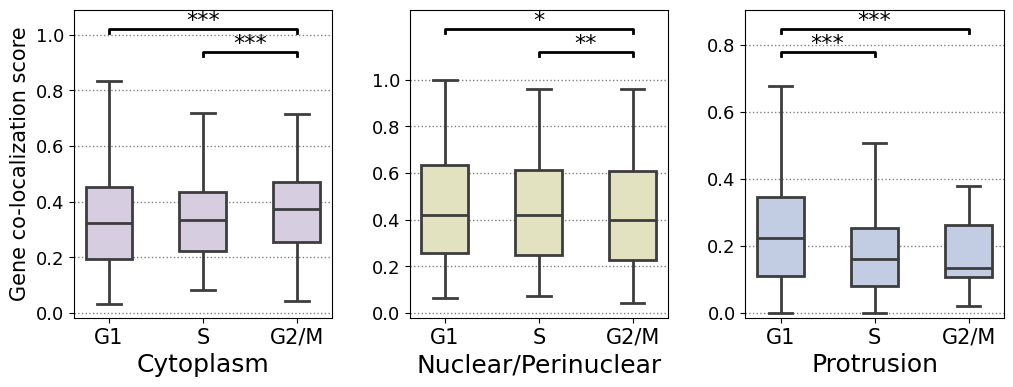

In [27]:
# Fig. 2l
def stars(p):
    return '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'

fig, ax = plt.subplots(1, 3, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.3})

for a, (name, color) in zip(ax, zip(blocks, ['#D7CAE4', '#e8e7bb', '#bccbe8'])):
    values = [pairs_by_phase[name][p] for p in PHASES]
    sns.boxplot(data=values, color=color, width=0.5, linewidth=2, showfliers=False, ax=a, zorder=10)

    # brackets stack above the tallest whisker; the narrower comparison sits lower
    top = max(np.percentile(v, 75) + 1.5 * (np.percentile(v, 75) - np.percentile(v, 25))
              for v in values)
    top = min(top, max(v.max() for v in values))
    step = 0.10 * top
    ordered = sorted(zip(PHASE_TESTS[name], pvals_phase[name]),
                     key=lambda t: abs(PHASES.index(t[0][0]) - PHASES.index(t[0][1])))
    for level, ((x, y), p) in enumerate(ordered):
        x1, x2 = sorted([PHASES.index(x), PHASES.index(y)])
        yb = top + (level + 1) * step
        a.plot([x1, x1, x2, x2], [yb, yb + step * 0.18, yb + step * 0.18, yb],
               color='black', lw=2, clip_on=False)
        a.text((x1 + x2) / 2, yb + step * 0.1, stars(p), ha='center', va='bottom', fontsize=16)

    a.set_ylim(-0.02 * top, top + 3 * step)
    _ylim = a.get_ylim()
    a.set_yticks([t for t in a.get_yticks() if t <= 1.0 + 1e-9])   # the score is a proportion
    a.set_ylim(*_ylim)
    a.set_xticks(range(3))
    a.set_xticklabels(PHASES, fontsize=15)
    a.set_xlabel(name, fontsize=18)
    a.tick_params(axis='y', labelsize=13)
    a.grid(axis='y', color='gray', linestyle=':', linewidth=1)

ax[0].set_ylabel('Gene co-localization score', fontsize=15)

plt.tight_layout()
plt.show()